<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/Pipeline_Telecustomer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report, roc_auc_score,roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as Skpipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Imbpipeline

In [2]:
df1=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/TelcomCustomer-Churn_1.csv',low_memory=False)
df2=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/TelcomCustomer-Churn_2.csv',low_memory=False)

In [3]:
df1.shape

(7043, 10)

In [4]:
df2.shape

(7043, 12)

In [5]:
df1.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
df2['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
df=pd.merge(df1,df2, on='customerID')

In [8]:
df.shape

(7043, 21)

In [9]:
df.select_dtypes('object').nunique()

,0
customerID,7043
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3


In [10]:
df['TotalCharges']=df['TotalCharges'].str.replace(' ','')

In [11]:
df['TotalCharges']=df['TotalCharges'].replace('',np.nan).astype('float64')

In [12]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [13]:
df.drop(['customerID'],axis=1,inplace=True)

In [14]:
df.select_dtypes('object').nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [15]:
df['DeviceProtection'].value_counts()

,count
DeviceProtection,
No,3095
Yes,2422
No internet service,1526


In [16]:
s=df.select_dtypes(include='object').columns.tolist()
for i in s:
  print(df[i].value_counts(),'\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64 

StreamingTV
No       

In [17]:
df.select_dtypes(exclude='object').nunique()

,0
SeniorCitizen,2
tenure,73
MonthlyCharges,1585
TotalCharges,6530


In [18]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [19]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [20]:
df['Churn']=df['Churn'].map({'No':0,'Yes':1}).astype('int64')

In [21]:
df.select_dtypes(exclude='object').nunique()

,0
SeniorCitizen,2
tenure,73
MonthlyCharges,1585
TotalCharges,6530
Churn,2


In [22]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.199484
tenure,-0.352229


In [23]:
df.select_dtypes(include='object').nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [24]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(['Churn'],axis=1),df['Churn'],test_size=0.2,random_state=1,stratify=df['Churn'])

In [25]:
X_train.shape

(5634, 19)

In [26]:
X_test.shape

(1409, 19)

In [27]:
num_col=X_train.select_dtypes('number').columns.tolist()
cat_col=X_train.select_dtypes('object').columns.tolist()

num_pipeline=Skpipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_pipeline=Skpipeline([('encode',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))])

preprocessor=ColumnTransformer([('num',num_pipeline,num_col),('cat',cat_pipeline,cat_col)])

In [28]:
pipe=Imbpipeline([
    ('preprocessor',preprocessor),
    ('sampling',SMOTE()),
    ('model',LogisticRegression())])

In [29]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('sampling', SMOTE()), ('model', LogisticRegression())])

In [30]:
y_pred_train=pipe.predict(X_train)
y_pred_test=pipe.predict(X_test)

In [55]:
y_probs=pipe.predict_proba(X_test)[:,1]
fpr,tpr,theshold=roc_curve(y_test,y_probs)
auc=roc_auc_score(y_test,y_probs)

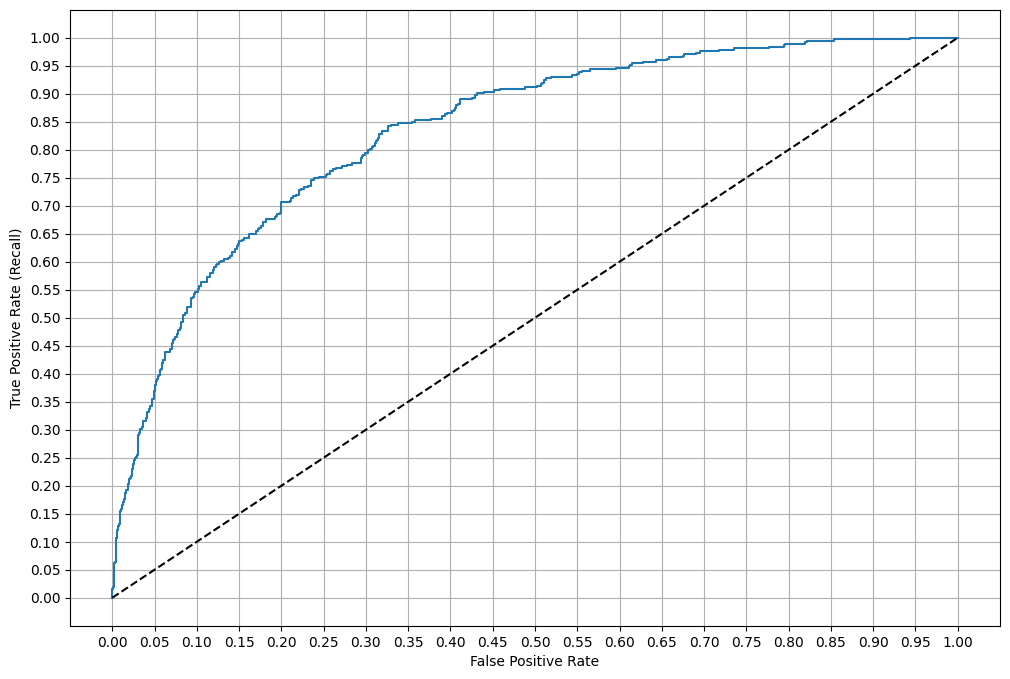

In [46]:
plt.figure(figsize=(12,8))
plt.plot(fpr,tpr,label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.plot([0, 1], [0, 1], 'k--')
plt.grid()
plt.xticks(np.arange(0,1.05,0.05))
plt.yticks(np.arange(0,1.05,0.05))
plt.show()

In [39]:
# finding right threshold
target_tpr = 0.85
target_fpr = 0.32
idx = np.argmin((tpr - target_tpr)**2 + (fpr - target_fpr)**2)
theshold[idx]

np.float64(0.41972499499104127)

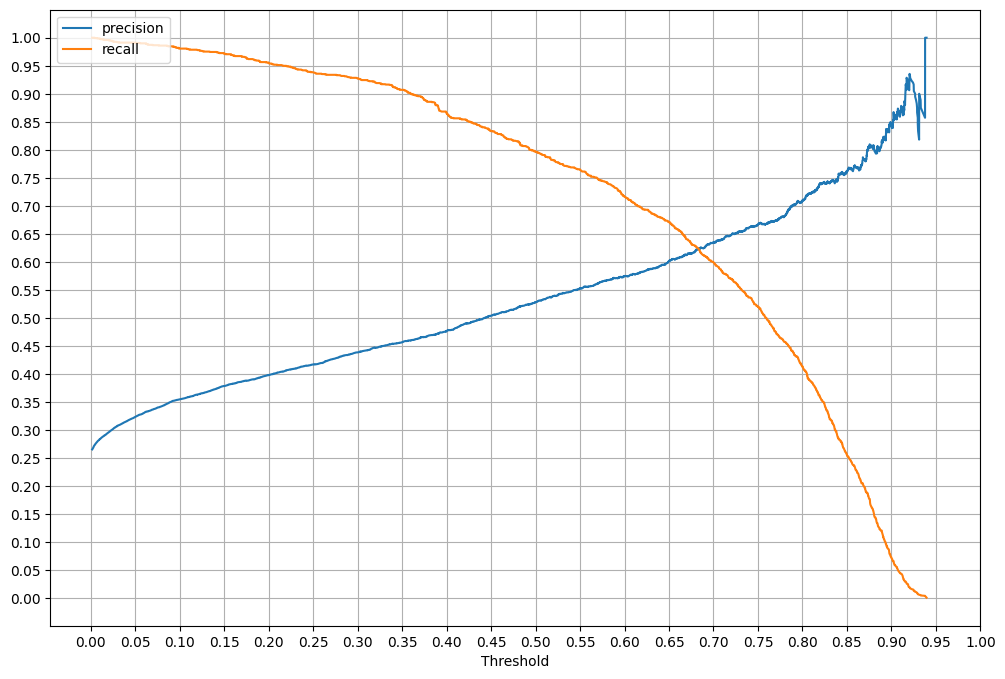

In [64]:
y_probs=pipe.predict_proba(X_train)[:,1]
precisions,recalls,thresholds=precision_recall_curve(y_train,y_probs)
plt.figure(figsize=(12,8))
plt.plot(thresholds,precisions[:-1], label='precision')
plt.plot(thresholds,recalls[:-1], label='recall')
plt.grid()
plt.xticks(np.arange(0,1.05,0.05))
plt.yticks(np.arange(0,1.05,0.05))
plt.xlabel('Threshold')
plt.legend(loc = 'upper left')
plt.show()

In [40]:
accuracy_score(y_test,y_pred_test)

0.7359829666430092

In [41]:
accuracy_score(y_train,y_pred_train)

0.7573659921902733

In [42]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409



In [43]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      4139
           1       0.53      0.80      0.64      1495

    accuracy                           0.76      5634
   macro avg       0.72      0.77      0.73      5634
weighted avg       0.81      0.76      0.77      5634

